In [0]:
# Execute this cell to install OpenMM in the Colab environment
!pip install -q openmm
# We also need to get a few files that the cookbook depends on
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/alanine-dipeptide.pdb'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential.pdb'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/initial_config.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/deca-ala.pdb'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential_3.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/hist.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/input.inpcrd'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/umbrella_sampling.svg'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential_2.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/cg_ff.xml'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/deca-alanine.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/villin.pdb'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/pmf.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/getting_started_1.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential_example_gold.xml'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/input.prmtop'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/equilibrated_config.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/getting_started_4.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/getting_started_3.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/alanine-dipeptide-water.pdb'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/1AKI-processed.cif'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential_1.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/constant_potential_4.png'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/sine.svg'
!wget -q 'https://raw.githubusercontent.com/openmm/openmm-cookbook/main/notebooks/tutorials/getting_started_2.png'

# Multistate Sampling 2: Expanded Ensemble

## Introduction

In the previous tutorial we ran a simulation with replica exchange, a popular algorithm for multistate sampling.  In this one we will look at a different algorithm called *expanded ensemble* sampling.  Recall the basic algorithm for replica exchange:

1. Initialize N replicas, each in a different thermodynamic state.
2. Simulate every replica for M steps.
3. Attempt to exchange states between replicas.

If we look at just a single replica, we see a continuous trajectory that periodically changes to a different thermodynamic state.  That is essentially what expanded ensembling sampling does.  It dispenses with the multiple replicas and uses a single simulation to sample all of the states.

1. Initialize a simulation to an initial thermodynamic state.
2. Simulate it for M steps.
3. Attempt to move to a different thermodynamic state.

Why would you prefer one method over the other?  It turns out that expanded ensemble sampling has certain theoretical advantages over replica exchange that make it more efficient.  The thermodynamic states can be further apart, allowing you to cover the same range with fewer states.  This comes at a cost in complexity and robustness, however.  In replica exchange, you are always simulating one replica in every state.  It is guaranteed that at the end, you will have an identical amount of sampling for every state.  Expanded ensemble does not have that guarantee.  It takes careful work to ensure that all states are properly sampled.

In practice this is done by choosing a *weight* for each thermodynamic state.  When attempting to move to a different state, the weights influence the transition probabilities.  Our goal is to choose weights that lead to spending approximately equal time in every state.  Fortunately, OpenMM can do this for you automatically.  It does take time for it to work out what the weights should be, so an expanded ensemble simulation usually begins with an initial period dedicated to choosing weights.  This initial period must be discarded when analyzing results.

## Running the Simulation

As in the previous tutorial, we will simulate alanine dipeptide in a box of water.  This time we will do a different type of simulation, one where thermodynamic states correspond to different values of a force field parameter.  We will do an umbrella sampling simulation, using a bias potential to make one dihedral remain close to a particular value.  Different states will correspond to different positions of the bias potential.  This lets us explore how the free energy varies as a function of that dihedral angle.

Let's start by creating the `System`, `Integrator`, and `Simulation`.  We use a `CustomTorsionForce` to apply a bias whose position depends on a global parameter.

In [1]:
from openmm import *
from openmm.app import *
from openmm.unit import *

pdb = PDBFile('alanine-dipeptide-water.pdb')
ff = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')
system = ff.createSystem(pdb.topology, nonbondedMethod=PME, constraints=HBonds, hydrogenMass=1.25*amu)
bias = CustomTorsionForce('100*min(dtheta, 2*pi-dtheta)^2; dtheta = abs(theta-theta0); pi = 3.1415926535')
bias.addGlobalParameter('theta0', 0)
bias.addTorsion(6, 8, 14, 16)
system.addForce(bias)
integrator = LangevinIntegrator(300*kelvin, 1.0/picosecond, 0.004*picoseconds)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

As with any simulation, we should equilibrate the system before we start the main simulation.

In [2]:
simulation.context.setVelocitiesToTemperature(300*kelvin)
simulation.step(10000)

In this case, our thermodynamic states correspond to different values of the global parameter `theta0`.  To specify this for multistate sampling, just use the name of the global parameter as the key.

In [3]:
import numpy as np

states = [{'theta0':t} for t in np.linspace(0.0, np.pi, 10)]

Performing expanded ensemble sampling is very similar to replica exchange.  We create an `ExpandedEnsembleSampler`, passing it the list of states, the `Simulation` object, and the interval in time steps at which to attempt state changes.

We also need to save results for later analysis.  Because expanded ensemble involves a single continuous simulation, you can mostly use standard reporters, for example to save a trajectory.  In addition, there are certain extra pieces of information specific to the expanded ensemble algorithm that you will often want to save.  `ExpandedEnsembleSampler` provides options to write them.  In this case we include the `logFile` argument.  It saves a CSV file recording what state the simulation is in at each iteration, as well as the values of the weights.

In [4]:
sampler = ExpandedEnsembleSampler(states, simulation, 100, logFile='log.csv', reportInterval=1000)
simulation.reporters.append(XTCReporter('trajectory.xtc', 1000, atomSubset=list(range(22))))

Now we're ready to run the simulation.

In [5]:
simulation.step(2000000)

## Analysis

Let's load the log and plot the weight factors.

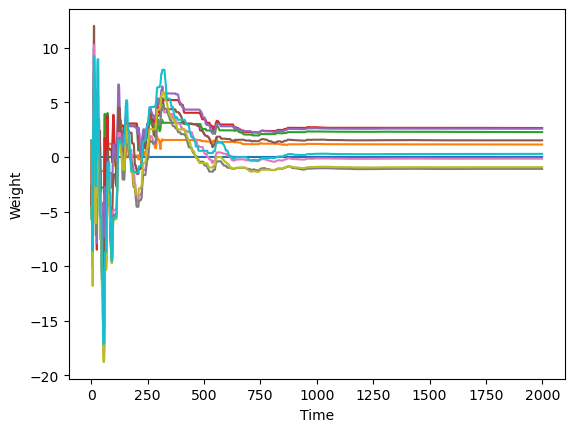

In [6]:
import matplotlib.pyplot as plot

log = np.loadtxt('log.csv', delimiter=',', skiprows=1)
plot.plot(log[:,3:])
plot.xlabel('Time')
plot.ylabel('Weight')
plot.show()

We see it took about 800,000 steps (800 reports) for the weights to converge.  We therefore should discard everything before that point when doing analysis.  It does not reflect a well defined distribution.

Now let's plot how the state varied over the simulation.  If the states were sufficiently close together, there should be frequent transitions to and from all states.

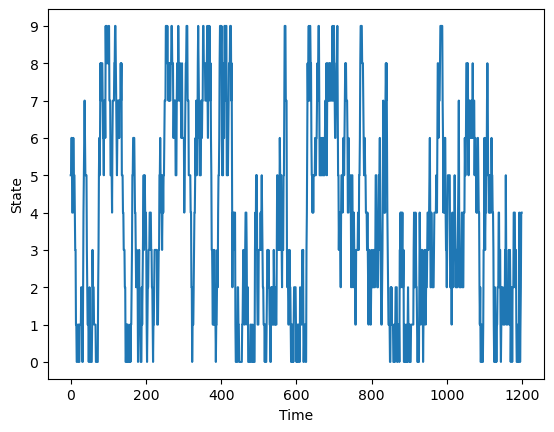

In [7]:
plot.plot(log[800:,2])
plot.xlabel('Time')
plot.ylabel('State')
plot.yticks(np.arange(10))
plot.show()

There are lots of transitions, indicating we have sufficient states.  Now let's look at the distribution of states.  In replica exchange, we are guaranteed to produce an identical amount of sampling for every state.  In expanded ensemble sampling, it depends on how good a job it has done of selecting weights.

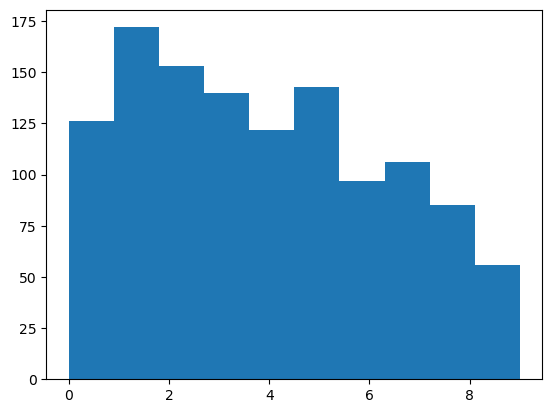

In [8]:
plot.hist(log[800:,2])
plot.show()

The distribution is fairly uniform, indicating it has done a good job of selecting weights.  It is not perfectly flat, but all states have a significant level of sampling.

Let's compute the dihedral angle for every frame in the trajectory and plot a histogram of them for each state.  If our biasing potential worked correctly, each state should have a different distribution of angles centered on a different point.

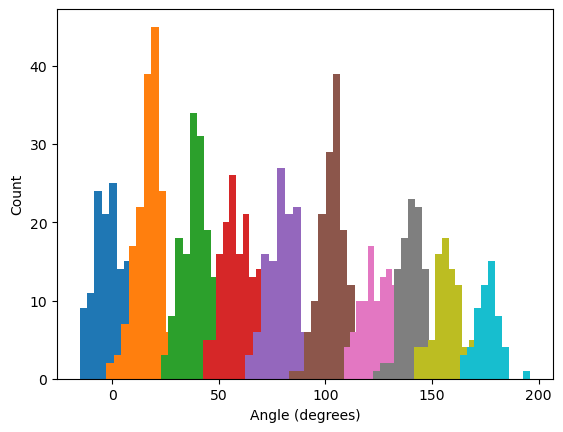

In [9]:
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Dihedral

u = mda.Universe('alanine-dipeptide.pdb', 'trajectory.xtc')
atoms = mda.AtomGroup([6, 8, 14, 16], u)
dihedral = Dihedral([atoms]).run()
wrapped = dihedral.results.angles + 360*(dihedral.results.angles < -90)
for state in range(len(states)):
    angles = [a for i, a in zip(log[800:,2], wrapped[800:,0]) if i == state]
    plot.hist(angles)
plot.xlabel('Angle (degrees)')
plot.ylabel('Count')
plot.show()

In an expanded ensemble simulation, the probability of finding the simulation in state $i$ is proportional to $\mathrm{exp}(w_i-F_i/k_B T_i)$ where $w_i$ is its weight factor, $F_i$ is its free energy, and $T_i$ is its temperature.  This means that, if `ExpandedEnsembleSampler` has done a perfect job of picking weights to give every state an equal probability, the free energy of each state is given by $k_B T_i w_i$.  Of course, it will not have done a perfect job and accurately computing free energy differences requires a more complicated analysis.  Nonetheless, it is still useful as a way of quickly estimating free energies.

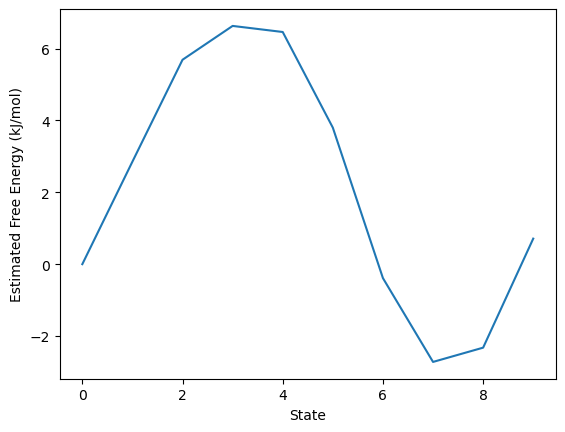

In [10]:
fe = [MOLAR_GAS_CONSTANT_R*integrator.getTemperature()*w for w in sampler.weights]
plot.plot([x.value_in_unit(kilojoules_per_mole) for x in fe])
plot.xlabel('State')
plot.ylabel('Estimated Free Energy (kJ/mol)')
plot.show()

## Next Steps

Our focus in this tutorial has been on how to use `ExpandedEnsembleSampler`, not on how to analyze an umbrella sampling simulation.  If you want to learn more about that, there is another tutorial that goes into much more detail about it.

## Links

- Tutorials
  - [Umbrella Sampling](https://openmm.github.io/openmm-cookbook/latest/notebooks/tutorials/umbrella_sampling.html)
- API Documentation
  - [ExpandedEnsembleSampler](https://docs.openmm.org/latest/api-python/generated/openmm.app.expandedensemblesampler.ExpandedEnsembleSampler.html)